In [197]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
book_img = cv2.imread('assignment_2_materials/cv_cover.jpg', cv2.COLOR_BGR2GRAY)
video = cv2.VideoCapture('assignment_2_materials/book.mov')
success, frame = video.read()

if not success:
    print("Error: Could not read video.")
    exit()

video.release()
gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

In [ ]:
sift_detector=cv2.SIFT_create()

# Detect keypoints and descriptors
keypoints1, descriptors1 = sift_detector.detectAndCompute(book_img, None)
keypoints2, descriptors2 = sift_detector.detectAndCompute(gray_frame, None)

# Match descriptors using KNN
bf = cv2.BFMatcher()
matches = bf.knnMatch(descriptors1, descriptors2, k=2)

# Apply ratio test
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)
good_matches = sorted(good_matches, key=lambda x: x.distance)

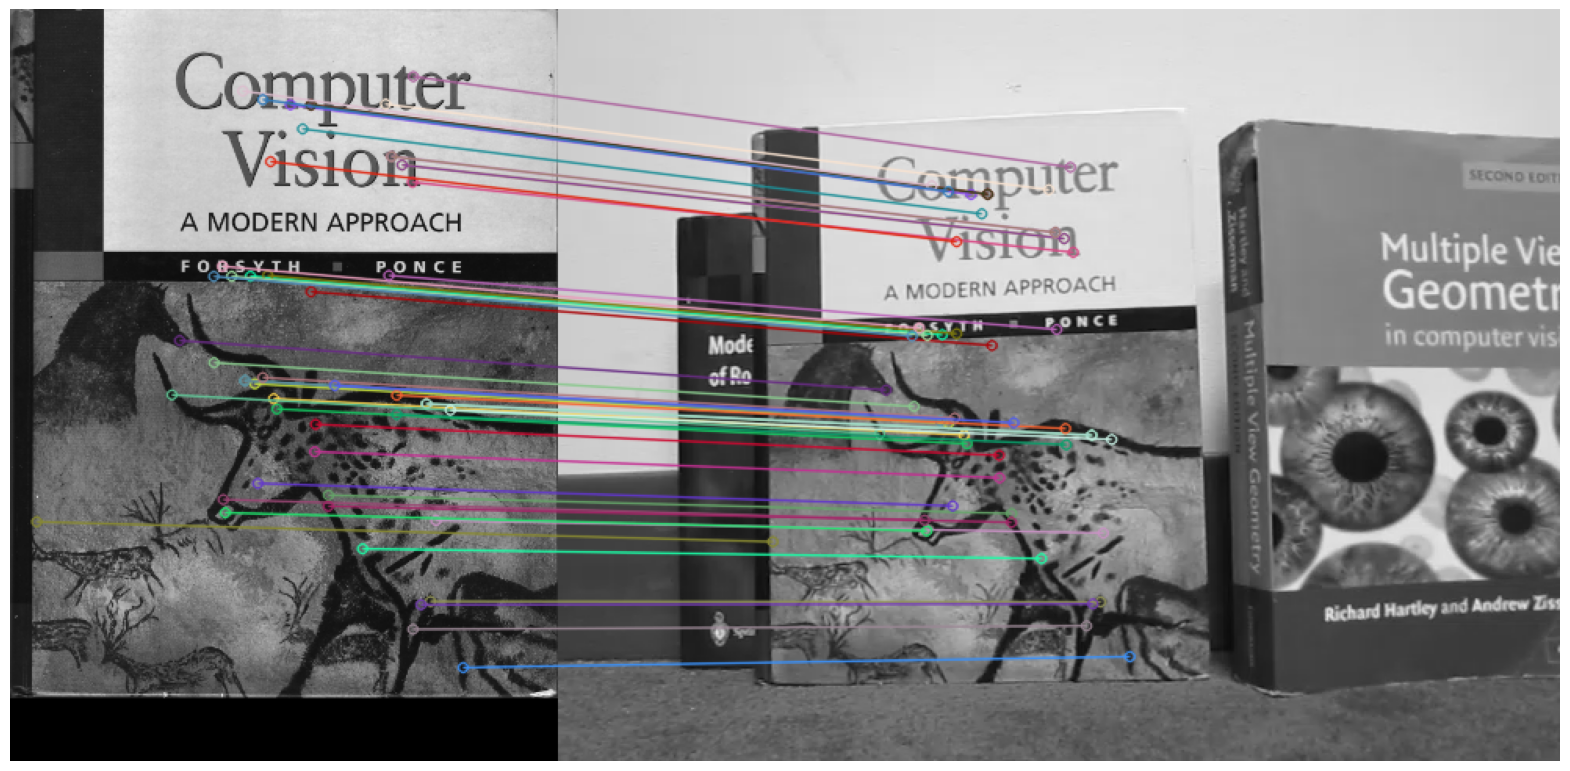

In [ ]:
good_matches = good_matches[:50]
img_matches = cv2.drawMatches(book_img, keypoints1, gray_frame, keypoints2, good_matches,None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(20, 10))
plt.imshow(img_matches)
plt.axis('off')
plt.show()

src_pts = np.float32([keypoints1[m.queryIdx].pt for m in good_matches])
dst_pts = np.float32([keypoints2[m.trainIdx].pt for m in good_matches])

In [201]:
def compute_homography(src_pts, dst_pts):

    if len(src_pts) < 4:
        raise ValueError("Need at least 4 points to compute homography")

    N = len(src_pts)
    A = []
    for i in range(N):
        (x, y) = src_pts[i]
        (xp, yp) = dst_pts[i]
        A.append([-x, -y, -1,  0,  0,  0, x * xp, y * xp, xp])
        A.append([ 0,  0,  0, -x, -y, -1, x * yp, y * yp, yp])

    A = np.array(A)

    # Solve using SVD: A*h = 0 -> smallest singular value
    U, S, Vt = np.linalg.svd(A)
    h = Vt[-1]  # Solution is last row of V^T
    H = h.reshape(3, 3)

    # Normalize so that H[2,2] == 1
    return H / H[2, 2]
def apply_homography(H, pts):
    pts_homog = np.hstack([pts, np.ones((pts.shape[0], 1))])
    projected = (H @ pts_homog.T).T
    projected /= projected[:, 2][:, np.newaxis]
    return projected[:, :2]


Homography Matrix:
[[ 7.73175746e-01  2.75722288e-03  1.19569964e+02]
 [-5.11103674e-02  7.78602152e-01  7.74981416e+01]
 [-9.11956120e-05 -7.43420640e-05  1.00000000e+00]]


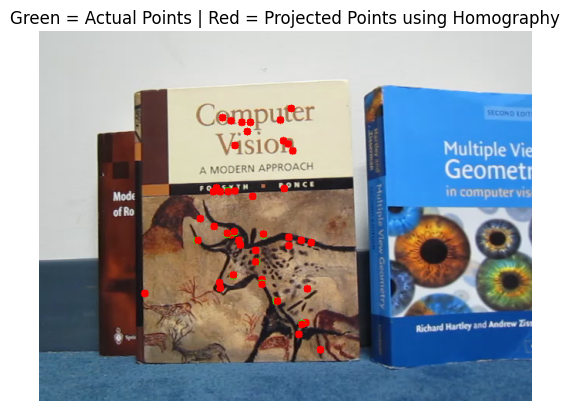

In [202]:
H=compute_homography(src_pts, dst_pts)
print("Homography Matrix:")
print(H)

projected_pts = apply_homography(H, src_pts)

draw = frame.copy()
# Draw the projected points on the original image
for actual, projected in zip(dst_pts, projected_pts):
    actual = tuple(np.round(actual).astype(int))
    projected = tuple(np.round(projected).astype(int))

    # Draw actual point (green)
    cv2.circle(draw, actual, 5, (0, 255, 0), -1)
    # Draw projected point (red)
    cv2.circle(draw, projected, 5, (0, 0, 255), -1)

plt.imshow(cv2.cvtColor(draw, cv2.COLOR_BGR2RGB))
plt.title("Green = Actual Points | Red = Projected Points using Homography")
plt.axis('off')
plt.show()

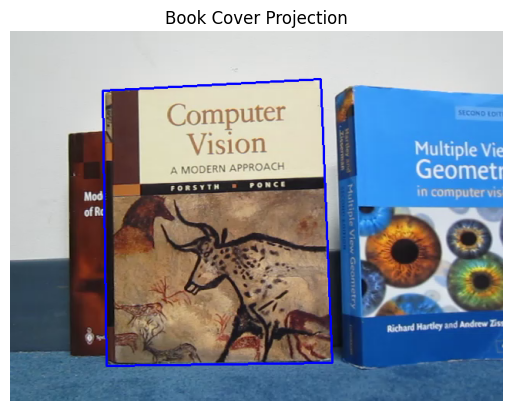

In [203]:
h, w = book_img.shape[:2]


book_corner = np.array([[0, 0], [w, 0], [w, h], [0, h]], dtype=np.float32)
mapped_corner = apply_homography(H, book_corner)

drawn = frame.copy()

mapped_corner = np.round(mapped_corner).astype(int)
cv2.line(drawn, tuple(mapped_corner[0]), tuple(mapped_corner[1]), (255, 0, 0), 2)
cv2.line(drawn, tuple(mapped_corner[1]), tuple(mapped_corner[2]), (255, 0, 0), 2)
cv2.line(drawn, tuple(mapped_corner[2]), tuple(mapped_corner[3]), (255, 0, 0), 2)
cv2.line(drawn, tuple(mapped_corner[3]), tuple(mapped_corner[0]), (255, 0, 0), 2)


# Convert the image from BGR to RGB for Matplotlib
drawn_rgb = cv2.cvtColor(drawn, cv2.COLOR_BGR2RGB)
# Display the image using Matplotlib
plt.imshow(drawn_rgb)
plt.title("Book Cover Projection")
plt.axis("off")
plt.show()

In [204]:
def crop_video_frame(ar_frame, h, w):
    book_aspect_ratio = w / h
    h_ar, w_ar = ar_frame.shape[:2]
    frame_aspect_ratio = w_ar / h_ar

    if frame_aspect_ratio > book_aspect_ratio:
        new_w = int(h_ar * book_aspect_ratio)
        x_offset = (w_ar - new_w) // 2
        cropped_frame = ar_frame[:, x_offset:x_offset + new_w]
    else:
        new_h = int(w_ar / book_aspect_ratio)
        y_offset = (h_ar - new_h) // 2
        cropped_frame = ar_frame[y_offset:y_offset + new_h, :]

    resized_frame = cv2.resize(cropped_frame, (w, h))
    return resized_frame

In [205]:
def crop_black_edges(image, threshold=10):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(mask)

    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        cropped = image[y:y+h, x:x+w]
        return cropped
    else:
        return image  # Return original if all black


(np.float64(-0.5), np.float64(349.5), np.float64(439.5), np.float64(-0.5))

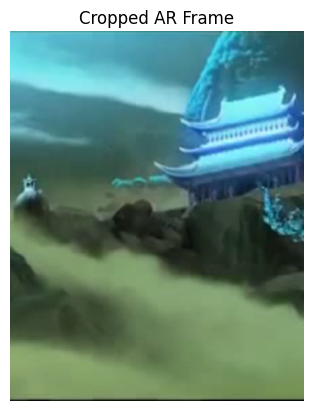

In [206]:
ar_source = cv2.VideoCapture('assignment_2_materials/ar_source.mov')

success, ar_frame = ar_source.read()
if not success:
    print("Failed to read the AR source video.")
    exit()
ar_source.release()
ar_frame = crop_black_edges(ar_frame)
cropped_ar = crop_video_frame(ar_frame, h, w)

# Show the cropped AR frame
plt.imshow(cropped_ar)
plt.title("Cropped AR Frame")
plt.axis("off")

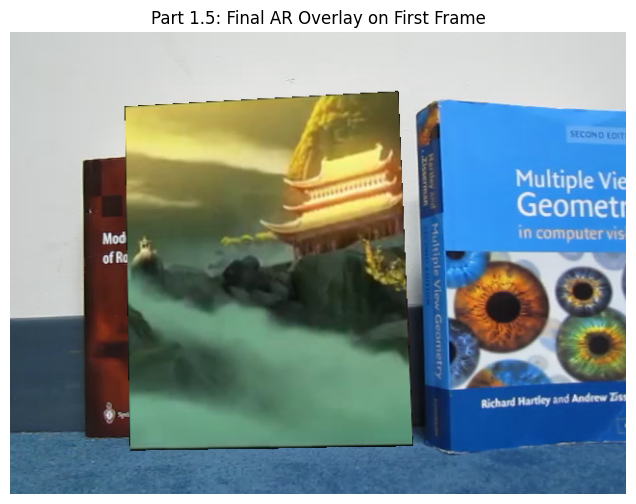

In [207]:
# Step 2: Warp the AR frame to the book's location using homography
warped_ar = cv2.warpPerspective(cropped_ar, H, (frame.shape[1], frame.shape[0]))

# Step 3: Create a binary mask from the warped AR frame
warped_gray = cv2.cvtColor(warped_ar, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(warped_gray, 1, 255, cv2.THRESH_BINARY)
mask = mask.astype(np.uint8)

# Step 4: Invert the mask to get the area to keep from original video frame
mask_inv = cv2.bitwise_not(mask)

# Step 5: Use masks to extract regions
frame_bg = cv2.bitwise_and(frame, frame, mask=mask_inv)
ar_fg = cv2.bitwise_and(warped_ar, warped_ar, mask=mask)

# Step 6: Combine both regions to get the final frame
final_overlay = cv2.add(frame_bg, ar_fg)

# Step 7: Display the final overlay result
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(final_overlay, cv2.COLOR_BGR2RGB))
plt.title("Final AR Overlay on First Frame")
plt.axis("off")
plt.show()